An Australian FMCG manufacturer and distributor wants to know whether its pricing is consistent across customers, product and regions - and where it isn't, to quantify the revenue impact.

In this notebook I fit a regression model on Average Sales Price for two years of transactional sales data. I use Cook's distance to diagnose and remove high-influence outliers, and quantify price leakage by customer to highlight potentially problamatic accounts.

Note I built this model for a real client diagnostic, and have had to recreate synthetic data to mimic that of the client. The generator script is in 'scripts/generate_synthetic.py'

## Setup

Imports and configuration.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm

PRICE_COL = "Unit Price"
PERIOD_Y0 = "Y0"
PERIOD_Y1 = "Y1"

# Feature columns for the regression
CATEGORICAL_FEATURES = ["Product Description", "State"]
NUMERIC_FEATURES = ["log_qty"]
FEATURE_COLS = CATEGORICAL_FEATURES + NUMERIC_FEATURES


## Data

The dataset is transactional sales data with one row per product sold to a customer in a given period. Each row captures Customer, Product (with its Category and Sub-category), Sales rep, State, Quantity sold, and Revenue.

There are two periods, labelled `Y0` and `Y1`, which each represent a full year of sales. There are roughly 100,000 transaction rows across 2,000 customers and 800 products.


In [16]:
df = pd.read_csv("../data/sales_synthetic.csv")

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 100,018
Columns: ['Customer Name', 'Cust Code', 'State', 'Rep', 'Product Category', 'Product Sub-Category', 'Product Description', 'Period', 'Qty', 'Revenue']


,Customer Name,Cust Code,State,Rep,Product Category,Product Sub-Category,Product Description,Period,Qty,Revenue
0,Customer 00001,C00001,VIC,Rep 13,Bakery,Bakery Sub 5,Product 0165,Y0,17.35,20.82
1,Customer 00001,C00001,VIC,Rep 13,Bakery,Bakery Sub 3,Product 0093,Y0,3.71,11.32
2,Customer 00001,C00001,VIC,Rep 13,Beverages,Beverages Sub 1,Product 0703,Y0,3.07,29.41
3,Customer 00001,C00001,VIC,Rep 13,Grocery,Grocery Sub 3,Product 0566,Y0,28.22,706.06
4,Customer 00001,C00001,VIC,Rep 13,Dairy,Dairy Sub 6,Product 0370,Y0,4.33,11.65


## Cleaning and feature engineering

Before modelling, a few small data preparation steps:

1. **Drop rows with zero or negative `Qty` or `Revenue`.** These are returns, credits, or data entry errors. Given this analysis is looking at pricing at the point of sale, we can reasonably remove Returns and Credits from the data - though with caution that the full revenue sum for the year will not be correct. Any data entry errors just produce noise which can be safely disregarded.
2. **Compute unit price** as `Revenue / Qty`. This is the target variable the regression will model.
3. **Log-transform quantity.** Volume discounting tends to be multiplicative rather than additive — a 10× increase in volume typically takes a roughly fixed *percentage* off the price, not a fixed dollar amount. Taking the log linearises this relationship.

In [17]:
df = df[df["Qty"] > 0]
df = df[df["Revenue"] > 0]

df[PRICE_COL] = df["Revenue"] / df["Qty"]
df["log_qty"] = np.log(df["Qty"])

# Drop any rows with missing values in the columns we care about.
key_cols = ["State", "Product Sub-Category", "Product Description",
            "Product Category", "Qty", PRICE_COL]
df = df.dropna(subset=key_cols)

print(f"Rows after cleaning: {len(df):,}")
df[[PRICE_COL, "log_qty"]].describe().round(2)

Rows after cleaning: 100,018


,Unit Price,log_qty
count,100018.00,100018.00
mean,8.61,3.62
std,8.39,1.67
min,0.50,0.00
25%,3.56,2.43
50%,6.32,3.36
75%,10.66,4.59
max,296.65,12.03


## Pricing model

We model unit price as a function of the product, the state, and (log) quantity purchased:

$$\text{Unit Price} = f(\text{Product}, \text{State}, \log(\text{Qty}))$$

Product and state are one-hot encoded; `log_qty` is passed through as a single numeric feature. We fit a separate linear regression for each period. 

In [18]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ("num", "passthrough", NUMERIC_FEATURES),
        ]
    )


def fit_period(df_period):
    """Fit a linear regression on a single period's data.
    Returns the fitted statsmodels result, the preprocessor, and the in-sample R².
    """
    preproc = make_preprocessor()
    X_enc = preproc.fit_transform(df_period[FEATURE_COLS]).toarray()
    X_sm = sm.add_constant(X_enc)
    y = df_period[PRICE_COL]

    result = sm.OLS(y, X_sm).fit()
    return result, preproc, result.rsquared


df_y0 = df[df["Period"] == PERIOD_Y0].copy()
df_y1 = df[df["Period"] == PERIOD_Y1].copy()

model_y0, preproc_y0, r2_y0 = fit_period(df_y0)
model_y1, preproc_y1, r2_y1 = fit_period(df_y1)

print(f"Y0: {len(df_y0):,} rows, R² = {r2_y0:.4f}")
print(f"Y1: {len(df_y1):,} rows, R² = {r2_y1:.4f}")


Y0: 50,009 rows, R² = 0.9657
Y1: 50,009 rows, R² = 0.8343


## Diagnosing the Y1 fit with Cook's distance

The Y1 R² of 0.83 is low enough to make me suspicious. Before accepting that Y1 pricing is genuinely messier than Y0, I want to check if there are any particular high-influence points dragging the fit.

Cook's distance is the standard tool for this. It asks a question of every row: *how much would all of the model's predictions move if I refit without this single row?* Rows where the answer is "a lot" are the ones distorting the coefficients.

### What Cook's distance measures

Two things can make a single row influential. It can sit far from the others in the feature space — leverage — meaning the regression has to reach for it. Or it can sit far from the fitted line — a large residual. 

Formally, for row i, Cook's distance is calculated as:

$$D_i = \frac{\sum_{j=1}^{n}(\hat{y}_j - \hat{y}_{j(i)})^2}{p \cdot \text{MSE}}$$

where $\hat{y}_{j(i)}$ is the prediction for row $j$ from a model refit with row $i$ removed, and $p$ is the number of parameters. This is a nightmare to compute, so we will use an equivalent closed form from statsmodels:

$$D_i = \frac{e_i^2}{p \cdot \text{MSE}} \cdot \frac{h_{ii}}{(1 - h_{ii})^2}$$

Here $e_i$ is the residual for row $i$, and $h_{ii}$ is the $i$-th diagonal of the hat matrix $H = X(X^\top X)^{-1} X^\top$ — the standard measure of leverage. This form highlights the "leverage × residual" calculation - you can literally see the residual term multiplying the leverage term, and a row only scores highly if both are nontrivial.

It also highlights a potential point of failure. When a row is the *only* observation with its particular combination of features — a product that only sold once, in one state — its leverage $h_{ii}$ is 1. The denominator $(1 - h_{ii})^2$ goes to zero and Cook's distance goes to infinity. I'll flag them alongside the genuinely high-Cook's rows and pull them out for the refit — a row whose fitted value is forced to equal its observed value carries no information about the underlying pricing pattern.

### The 4/n threshold

A common rule of thumb is to flag rows where $D_i > 4/n$. For the ~50k Y1 rows I'm working with, that puts the threshold around $8 \times 10^{-5}$.

In [ ]:
df_y1 = df_y1.copy()
df_y1["Cooks_D"] = model_y1.get_influence().cooks_distance[0]

# Flag rule: above the 4/n threshold, OR NaN/inf (singleton rows
# with leverage ≈ 1, which blow up the closed-form denominator)
n = len(df_y1)
cooks_threshold = 4 / n

df_y1["Cooks_Flag"] = (
    (df_y1["Cooks_D"] > cooks_threshold)
    | df_y1["Cooks_D"].isna()
    | np.isinf(df_y1["Cooks_D"])
)

n_flagged = int(df_y1["Cooks_Flag"].sum())
share_flagged = df_y1["Cooks_Flag"].mean()

print(f"Y1 rows: {n:,}")
print(f"Cook's distance threshold (4/n): {cooks_threshold:.2e}")
print(f"Rows flagged: {n_flagged:,} ({share_flagged:.2%})")


Y1 rows: 50,009
Cook's distance threshold (4/n): 8.00e-05
Rows flagged: 793 (1.59%)


### Pause...

It's worth stepping back a moment to understand why we are computing Cook's distance and what these 793 points are doing. The working hypothesis is that these 793 points are disproportionately influencing the model coefficients: the coefficients are chosen by the model to reduce the squared error on these few high-influence rows, even if it means fitting the bulk of the data worse. Pulling these points out lets the regression better fit against the bulk of the data. 

But - these flagged points may be transactions representing legitimate, important pricing decisions (eg. a large negotiated deal with a major customer). Removing them may be analytically convenient, but the ultimate goal is not just to build a regression model with a strong R^2 - it's to identify revenue leakage through pricing. These points need to be understood before they're discarded.




### Inspecting the flagged rows

Before deciding whether to refit without these rows, I want to understand what they look like. A few questions:

- How much revenue do they represent?
- Are they concentrated in particular states, categories, or customers?
- What do the biggest ones look like individually?

In [20]:
flagged = df_y1[df_y1["Cooks_Flag"]]

# Aggregate picture: how many rows, how much revenue, where they sit
flagged_revenue = flagged["Revenue"].sum()
y1_revenue = df_y1["Revenue"].sum()
print(f"Flagged rows: {len(flagged):,} of {len(df_y1):,} ({len(flagged)/len(df_y1):.2%})")
print(f"Flagged revenue: ${flagged_revenue:,.0f} of ${y1_revenue:,.0f} "
      f"({flagged_revenue/y1_revenue:.2%} of Y1 revenue)")
print()

print("Flagged rows by state:")
print(flagged["State"].value_counts(normalize=True).round(3).to_string())
print()
print("Flagged rows by product category:")
print(flagged["Product Category"].value_counts(normalize=True).round(3).to_string())

Flagged rows: 793 of 50,009 (1.59%)
Flagged revenue: $6,208,073 of $67,869,081 (9.15% of Y1 revenue)

Flagged rows by state:
State
NSW    0.368
VIC    0.256
QLD    0.137
WA     0.090
SA     0.068
TAS    0.061
NT     0.020

Flagged rows by product category:
Product Category
Dairy        0.347
Bakery       0.276
Grocery      0.207
Frozen       0.107
Beverages    0.063


In [21]:
# Compare flagged vs overall Y1 distribution for state and category
comparison_state = pd.DataFrame({
    "Flagged": flagged["State"].value_counts(normalize=True),
    "All Y1": df_y1["State"].value_counts(normalize=True),
}).fillna(0).round(3)
print("State distribution — flagged vs all Y1:")
print(comparison_state.to_string())
print()

comparison_cat = pd.DataFrame({
    "Flagged": flagged["Product Category"].value_counts(normalize=True),
    "All Y1": df_y1["Product Category"].value_counts(normalize=True),
}).fillna(0).round(3)
print("Product category distribution — flagged vs all Y1:")
print(comparison_cat.to_string())
print()

# Top 10 flagged rows by revenue — the ones most worth scrutinising
print("Top 10 flagged rows by revenue:")
top_flagged = (
    flagged
    .nlargest(10, "Revenue")
    [["Customer Name", "State", "Product Category", "Product Description",
      "Qty", "Revenue", PRICE_COL, "Cooks_D"]]
)
print(top_flagged.to_string(index=False))

State distribution — flagged vs all Y1:
       Flagged  All Y1
State                 
NSW      0.368   0.375
NT       0.020   0.014
QLD      0.137   0.159
SA       0.068   0.075
TAS      0.061   0.038
VIC      0.256   0.271
WA       0.090   0.068

Product category distribution — flagged vs all Y1:
                  Flagged  All Y1
Product Category                 
Dairy               0.347   0.267
Bakery              0.276   0.216
Grocery             0.207   0.211
Frozen              0.107   0.175
Beverages           0.063   0.131

Top 10 flagged rows by revenue:
 Customer Name State Product Category Product Description     Qty   Revenue  Unit Price  Cooks_D
Customer 01538   NSW           Bakery        Product 0099 9187.32 491521.62   53.500000 0.000134
Customer 00139   VIC           Frozen        Product 0440 7653.04 388927.49   50.820000 0.001322
Customer 01538   NSW           Frozen        Product 0405 4739.79 254621.52   53.720000 0.001312
Customer 01538   NSW           Bakery     

These flagged rows are high-value transactions, and removing them feels like discarding real business. If the goal were simply to predict unit price across all transactions, then removing them would be unreasonable. But the goal is specifically to build a baseline against which to measure deviations — and if a small set of transactions is influential enough to shape the baseline itself, the baseline becomes contaminated by the very anomalies we're trying to detect. A customer whose pricing is 30% off the market rate, but whose volume is large enough to drag the fitted coefficients toward their own prices, will have a small residual in the fitted model and will never surface as leakage. Removing these rows from the fitting step — while keeping them in the scoring step — is what allows the legitimate leakage to be surfaced.

It's worth flagging what the top 10 flagged rows already show: nine of them come from just two customers. If the leakage analysis is working, these same customers should appear at the top of the final leakage ranking, because the clean model will no longer be absorbing their prices into the baseline.

So yes, we will now remove them from the next model fit, but they are not being discarded altogether - they will almost certainly appear as the outliers when we arrive at the scoring step.

### Refitting Y1 without the high-influence rows

We refit the Y1 model on everything except the Cook's-flagged rows, using the same `fit_period` function as before. The goal is a baseline whose coefficients are determined by the bulk of the data rather than the small set of high-leverage points we just identified.

Important: this is a fitting step, not a deletion. Every row — flagged or not — will still be scored against this cleaner model in the leakage section. The flagged rows simply don't get a vote on what the baseline looks like.

In [22]:
df_y1_clean = df_y1[~df_y1["Cooks_Flag"]].copy()

model_y1_clean, preproc_y1_clean, r2_y1_clean = fit_period(df_y1_clean)

print(f"Y1 rows used for refit: {len(df_y1_clean):,} "
      f"(removed {df_y1['Cooks_Flag'].sum():,} flagged rows)")
print()
print(f"Y0 R² (unchanged):       {r2_y0:.4f}")
print(f"Y1 R² (original fit):    {r2_y1:.4f}")
print(f"Y1 R² (Cook's removed):  {r2_y1_clean:.4f}")

Y1 rows used for refit: 49,216 (removed 793 flagged rows)

Y0 R² (unchanged):       0.9657
Y1 R² (original fit):    0.8343
Y1 R² (Cook's removed):  0.9712


## Scoring and residual analysis

With both per-period models in place — the original Y0 model and the Cook's-cleaned Y1 model — we now score every row in the dataset. Each row gets an **expected price** from the model that corresponds to its period, and a **price gap** equal to actual minus expected.

A negative price gap means the customer paid less than the model would predict — the signal we ultimately want to surface as leakage. Before aggregating to the customer level, we want to understand the overall shape and distribution of Price Gap and Price Gap %.

In [23]:
def add_expected_and_gaps(df_period, model, preproc):
    """Add Expected Price and Price Gap columns for a single period."""
    out = df_period.copy()
    X_enc = preproc.transform(out[FEATURE_COLS]).toarray()
    out["Expected Price"] = model.predict(sm.add_constant(X_enc))
    out["Price Gap"] = out[PRICE_COL] - out["Expected Price"]
    out["Price Gap %"] = out["Price Gap"] / out["Expected Price"]
    return out


df_y0_scored = add_expected_and_gaps(df_y0, model_y0, preproc_y0)
df_y1_scored = add_expected_and_gaps(df_y1, model_y1_clean, preproc_y1_clean)

scored = pd.concat([df_y0_scored, df_y1_scored], ignore_index=True)

print("Price Gap % distribution:")
print(scored["Price Gap %"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(3))
print()

# Tail share — what fraction of rows have extreme gaps?
abs_gap = scored["Price Gap %"].abs()
for cutoff in [0.20, 0.50, 1.00, 2.00, 5.00]:
    share = (abs_gap > cutoff).mean()
    print(f"  |Price Gap %| > {cutoff*100:>4.0f}%: {share:.4%}")


Price Gap % distribution:
count    100018.000
mean         -0.293
std         104.686
min      -32560.448
1%           -0.741
5%           -0.283
25%          -0.083
50%           0.003
75%           0.072
95%           0.408
99%           2.345
max        1882.596
Name: Price Gap %, dtype: float64

  |Price Gap %| >   20%: 20.7353%
  |Price Gap %| >   50%: 5.5960%
  |Price Gap %| >  100%: 3.1534%
  |Price Gap %| >  200%: 1.9227%
  |Price Gap %| >  500%: 0.7099%



The reason we are particularly interested in Price Gap % rather than just Price Gap is because % Gap is a stronger metric commercially - eg. if we can say a particular customer is getting a product for 25% below expected price - this is a stronger signal than saying they are getting it for $4 below expected price. However, using the % Gap does come with some downfalls with regards to summary statistics.

We see the middle of the distribution looks fine - median is 0.003 and 75% of rows fall between is -8% to +7% (IQR). However we also see the outliers are heavily influencing some of the summary statistics. eg. 253 is not a reasonable standard deviation; the max of 79,918% and min of -4,507% are also wild. This is likely where the model predicts a low price for some unusual Product / State combination, and the actual price is much higher - here we get an extreme Price Gap %. Eg. if we had a prediction of $0.10 and an actual price of $80, the Price Gap % would be c.80,000% - the dollar gap may be small, but the % explodes. So we must be careful when reporting summary statistics on the Price Gap %. 

Note these outliers aren't a problem on their own, but in order to report the summary statistics of the Price Gap %, we would want to remove these. This can be done through Winsorisation - where the variable Price Gap % will be capped at some chosen percentile.

We will winsorise `Price Gap %` at its 95th percentile. This means for all rows where the Price Gap % is above the 95% percentile, the value will be fixed to be that at the 95th percentile. We'll use the winsorised version for any reporting or summary statistics. The dollar gap stays untouched and remains the basis for the leakage calculation.


In [24]:
# Winsorise Price Gap % at the 95th percentile of its absolute value.
# Leaves Price Gap (dollars) untouched — leakage aggregation uses that.
abs_gap = scored["Price Gap %"].abs()
cap = abs_gap.quantile(0.95)
scored["Price Gap % Winsor"] = scored["Price Gap %"].clip(lower=-cap, upper=cap)

print(f"Winsorisation cap: ±{cap:.2%}")
print()
print("Price Gap % Winsor distribution:")
print(scored["Price Gap % Winsor"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(3))
print()

# Sanity check: % of rows within typical commercial tolerances
abs_winsor = scored["Price Gap % Winsor"].abs()
for cutoff in [0.10, 0.20, 0.50]:
    share = (abs_winsor <= cutoff).mean()
    print(f"  Within ±{cutoff*100:.0f}%: {share:.2%}")

Winsorisation cap: ±55.28%

Price Gap % Winsor distribution:
count    100018.000
mean          0.006
std           0.191
min          -0.553
1%           -0.553
5%           -0.283
25%          -0.083
50%           0.003
75%           0.072
95%           0.408
99%           0.553
max           0.553
Name: Price Gap % Winsor, dtype: float64

  Within ±10%: 58.34%
  Within ±20%: 79.26%
  Within ±50%: 94.40%


We see the mean now sits around 0, with std at 0.191, and the IQR roughly the same. This confirms our cap only affected the tails and didn't squash the middle. These updated summary statistics may be useful to draw upon. In particular, the std of 0.191 roughly tells us a row's typical price point is about 19% away from expected. Standalone, this doesn't tell us much. but with commercial context this can be a powerful statistic. For a commoditised good, this would be erratic; for a negotiated market, this is more steady.

## Quantifying leakage

With the model and clean residuals in place, we can now compute leakage. For each row:

$$\text{Leakage} = -\text{Price Gap} \times \text{Qty}$$

A customer paying *less* than the model expects has a negative price gap, and the negation makes their leakage positive — i.e. positive leakage represents money the business is leaving on the table. We sum across all of a customer's transactions in both periods to get a total leakage figure per customer.

Note: this uses the **dollar** price gap, not the winsorised percentage. The percentage was only winsorised for clean summary statistics; the dollar gap is what actually represents money, and it doesn't have the small-denominator problem.

In [25]:
scored["Leakage"] = -scored["Price Gap"] * scored["Qty"]

customer_leakage = (
    scored
    .groupby("Customer Name")
    .agg(
        Total_Leakage=("Leakage", "sum"),
        Total_Qty=("Qty", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Line_Count=("Leakage", "size"),
    )
    .sort_values("Total_Leakage", ascending=False)
)

# Headline numbers
total_positive_leakage = customer_leakage[customer_leakage["Total_Leakage"] > 0]["Total_Leakage"].sum()
top_5_leakage = customer_leakage.head(5)["Total_Leakage"].sum()
top_5_share = top_5_leakage / total_positive_leakage

print(f"Total positive leakage across all customers: ${total_positive_leakage:,.0f}")
print(f"Top 5 customers' leakage:                    ${top_5_leakage:,.0f}")
print(f"Top 5 share of positive leakage:             {top_5_share:.1%}")
print()
print("Top 10 customers by leakage:")
print(customer_leakage.head(10).round(0).to_string())

Total positive leakage across all customers: $4,370,743
Top 5 customers' leakage:                    $4,077,518
Top 5 share of positive leakage:             93.3%

Top 10 customers by leakage:
                Total_Leakage  Total_Qty  Total_Revenue  Line_Count
Customer Name                                                      
Customer 01538      2262891.0  8789311.0     50158947.0        4628
Customer 01629       867353.0  1315207.0      7720267.0        1770
Customer 00845       491132.0   577754.0      2915163.0        1202
Customer 01041       337114.0   378588.0      2491097.0         944
Customer 01533       119028.0    86620.0       505106.0         444
Customer 01049        82510.0   129357.0       866174.0         568
Customer 01216        57077.0    42171.0       255723.0         324
Customer 01634         8228.0     4587.0        41685.0          88
Customer 00691         8168.0    11725.0        64160.0         144
Customer 00916         6373.0     8607.0        58489.0    

A few things worth pulling out:

- **The leakage is extremely concentrated.** The top 5 customers account for 93% of positive leakage, totalling around $4.1m. If a commercial team wanted to act on this analysis, the entire opportunity is contained in a handful of accounts.
- **Customer 01538 dominates.** $2.26m of leakage by themselves — more than half the total. Unsurprisingly, this is the same customer who appeared repeatedly in the Cook's distance flagged rows earlier. As we would expect, removing them from the fitting step let us build a clean baseline, and scoring them against that baseline surfaces them as drivers of revenue leakage.
- **The leakage profile differs by customer type.** Customer 01538 is a $50m revenue account with around 1% leakage — small per-line discounts compounding across large volumes. Customer 00845 is a $2.9m account with about 17% leakage — much more dramatically discounted but a smaller absolute number. These are different commercial conversations: the first is about tightening pricing discipline at scale, the second is likely about renegotiating a specific deal.

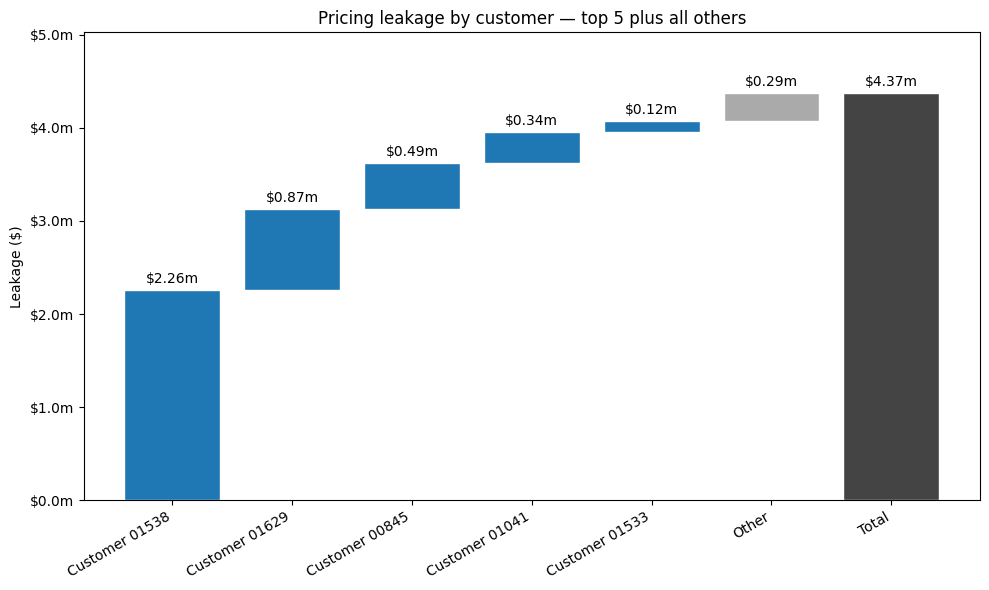

In [26]:
# Top 5 customers by leakage, plus an "Other" bucket and a final "Total" bar
top_5 = customer_leakage.head(5)["Total_Leakage"]
other = total_positive_leakage - top_5.sum()

labels = list(top_5.index) + ["Other", "Total"]
values = list(top_5.values) + [other, total_positive_leakage]

# Build the waterfall: each non-total bar starts at the running total before it
running = 0
bottoms = []
heights = []
colours = []
for i, v in enumerate(values):
    if labels[i] == "Total":
        bottoms.append(0)
        heights.append(v)
        colours.append("#444444")  # neutral grey for the total
    else:
        bottoms.append(running)
        heights.append(v)
        colours.append("#1f77b4" if labels[i] != "Other" else "#aaaaaa")
        running += v

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, heights, bottom=bottoms, color=colours, edgecolor="white")

# Annotate each bar with its $ value
for i, (b, h) in enumerate(zip(bottoms, heights)):
    ax.text(i, b + h + total_positive_leakage * 0.01,
            f"${h/1e6:.2f}m", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Leakage ($)")
ax.set_title("Pricing leakage by customer — top 5 plus all others")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}m"))
ax.set_ylim(0, total_positive_leakage * 1.15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Findings

- **The model fits the bulk of pricing well.** A linear regression on product, state, and log-quantity explains around 97% of unit-price variation in both periods (Y0 directly, Y1 after removing 793 high-influence rows flagged by Cook's distance). The structure captures most of the legitimate drivers of price.

- **Pricing leakage is highly concentrated.** Across both periods, around $4.4m in positive leakage sits with the customer base. **The top 5 customers account for 93% of it**, with one account (Customer 01538) alone responsible for $2.3m — more than half the total.

- **The diagnostic and the leakage analysis tell a consistent story.** The customers whose transactions disproportionately influenced the original Y1 fit — the rows Cook's distance flagged — turn out to be the same customers whose pricing is systematically off the model. Removing them from the fitting step gave us a clean baseline; scoring them against that baseline surfaces them as leakage drivers.

## Limitations

A few honest caveats:

- **The model assumes price is linear in log-quantity and additive across product and state effects.** Real pricing relationships may have interactions (e.g. specific products priced differently in specific states) that this model can't capture. The Cook's distance step mitigates this somewhat by flagging rows the model can't explain, but a more flexible model could be worth exploring.

- **No commercial context.** Customers on long-term contracts or volume commitments may legitimately pay below market rates. Without that data, the model can't distinguish "leakage" from "negotiated discount." The output here should be treated as a *hypothesis-generation* tool — flagging accounts worth investigating, without drawing full conclusions.

- **The analysis is fitted on synthetic data** that mirrors the structure of a real client dataset. The methodology and findings reflect what would emerge from the real engagement, but the specific dollar figures and customer codes are illustrative.

## Next steps

- **The natural next step is a commercial investigation of the top five.** Each of these customers should be reviewed against their contract terms, account history, and sales rep relationships to determine the root causes of the leakage.

